In [ ]:
import pandas as pd
import koreanize_matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:
with open('C:/Users/User/고급프로젝트/part4_pj/accounts_attendance.csv', encoding= 'utf-8') as f:
    lines = f.readlines()
    data = []
    for line in lines[1:]:
        # id, attendance_date_list, user_id 분리
        first_comma = line.find(',') # 콤마 찾기
        last_comma = line.rfind(',') # 오른쪽 콤마 찾기
        id_val = line[:first_comma].strip() # 공백 제거하자
        attendance_str = line[first_comma+1:last_comma].strip().strip('"') # 공백 제거하기
        user_id = line[last_comma+1:].strip()

        # 리스트 문자열을 실제 리스트로 변환
        attendance_list = [d.strip().strip('"') for d in attendance_str.strip('[]').split(',') if d.strip()]
        data.append([id_val, attendance_list, user_id])
    accounts_attendance_df = pd.DataFrame(data, columns=['id', 'attendance_date_list', 'user_id'])
accounts_attendance_df

,id,attendance_date_list,user_id
0,1,"[2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...",1446852
1,2,"[2023-05-27, 2023-05-29, 2023-05-30, 2023-06-0...",1359398
2,3,"[2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...",1501542
3,4,"[2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...",1507767
4,5,"[2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...",1287453
...,...,...,...
995,1020,"[2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...",1009278
996,1021,"[2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...",1434012
997,1022,"[2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...",1432423
998,1023,"[2023-05-27, 2023-05-30, 2023-06-05]",958207


In [44]:
accounts_attendance_df.isna().sum()

id                      0
attendance_date_list    0
user_id                 0
dtype: int64

In [47]:
accounts_attendance_df['attendance_str'] = accounts_attendance_df['attendance_date_list'].apply(lambda x : ','.join(x) )
accounts_attendance_df['attendance_str'].duplicated().sum()

np.int64(184)

In [56]:
accounts_attendance_df = accounts_attendance_df.drop_duplicates(subset=['attendance_str'])
accounts_attendance_df['attendance_str'] = accounts_attendance_df['attendance_str'].drop_duplicates().values
accounts_attendance_df[accounts_attendance_df['attendance_str'].duplicated()]

,id,attendance_date_list,user_id,attendance_str


In [57]:
# 문자열을 리스트로 변환
accounts_attendance_df['attendance_date_list'] = accounts_attendance_df['attendance_str'].apply(
    lambda x: [d.strip() for d in x.split(',')] if isinstance(x, str) else []
)
accounts_attendance_df['attendance_date_list']

0      [2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...
1      [2023-05-27, 2023-05-29, 2023-05-30, 2023-06-0...
2      [2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...
3      [2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...
4      [2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...
                             ...                        
994    [2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...
995    [2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...
996    [2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...
997    [2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...
998                 [2023-05-27, 2023-05-30, 2023-06-05]
Name: attendance_date_list, Length: 817, dtype: object

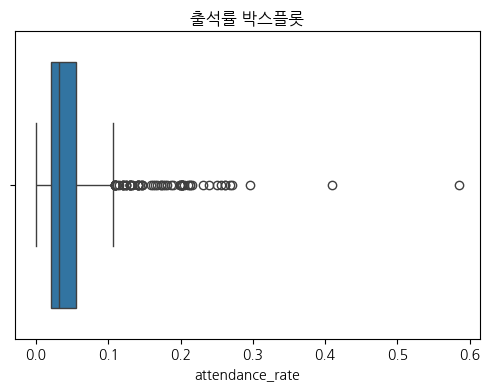

In [72]:
# 출석일수 계산
accounts_attendance_df['attendance_count'] = accounts_attendance_df['attendance_date_list'].apply(len)

# 전체 날짜 모으기 (빈 문자열 제거)
all_dates = [d for lst in accounts_attendance_df['attendance_date_list'] for d in lst if d.strip() != '']

# 문자열을 datetime으로 변환
all_dates_dt = [datetime.strptime(d, "%Y-%m-%d") for d in all_dates]

min_date = min(all_dates_dt)
max_date = max(all_dates_dt)
total_days = (max_date - min_date).days + 1
# 유저별 출석률 계산(빈 리스트 처리)
def user_attendance_rate(lst):
    # 빈 리스트 처리
    if not lst:
        return 0
    
    # 빈 문자열 제거
    lst_clean = [d for d in lst if isinstance(d, str) and d.strip() != '']
    if not lst_clean:
        return 0
    
    # 문자열을 datetime으로 변환
    lst_dt = [datetime.strptime(d, "%Y-%m-%d") for d in lst_clean]
    
    # 유저별 활동 기간 계산
    min_d, max_d = min(lst_dt), max(lst_dt)
    total_days = (max_d - min_d).days + 1
    
    return len(lst_dt) / total_days
# 출석률 계산
accounts_attendance_df['attendance_rate'] = accounts_attendance_df['attendance_count'] / total_days



# 박스플롯
plt.figure(figsize=(6,4))
sns.boxplot(x=accounts_attendance_df['attendance_rate'])
plt.title("출석률 박스플롯")
plt.show()

In [70]:
# 유저별 활동 기간 기준 출석률
accounts_attendance_df['attendance_rate_user_period'] = accounts_attendance_df['attendance_date_list'].apply(user_attendance_rate)

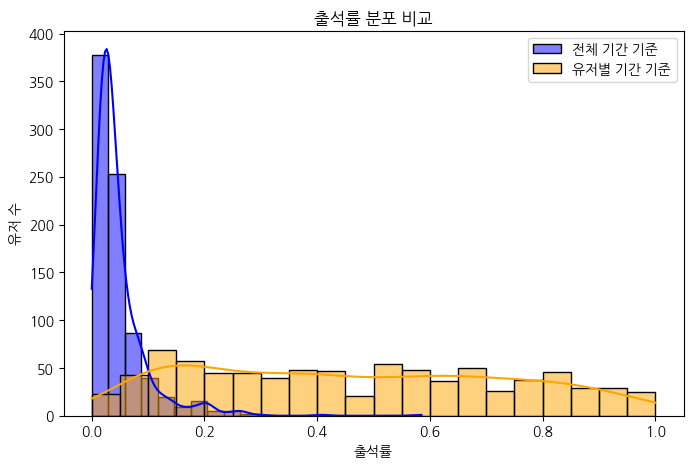

In [71]:
plt.figure(figsize=(8,5))
sns.histplot(accounts_attendance_df['attendance_rate'], bins=20, color='blue', label='전체 기간 기준', kde=True)
sns.histplot(accounts_attendance_df['attendance_rate_user_period'], bins=20, color='orange', label='유저별 기간 기준', kde=True)
plt.title("출석률 분포 비교")
plt.xlabel("출석률")
plt.ylabel("유저 수")
plt.legend()
plt.show()

In [74]:
# 상위 10명 유저
top_users = accounts_attendance_df.sort_values('attendance_rate_user_period', ascending=False).head(10)
print(top_users[['user_id','attendance_rate_user_period']])


     user_id  attendance_rate_user_period
320  1346103                          1.0
15   1515683                          1.0
900  1458808                          1.0
54   1423477                          1.0
480  1430929                          1.0
91   1177828                          1.0
565  1421796                          1.0
177  1352437                          1.0
350  1461113                          1.0
373  1524749                          1.0
